# AI Model Experiment & Evaluation
**Starter Notebook**

Notebook ini adalah kerangka awal untuk membandingkan dua pendekatan AI dalam menyelesaikan task sentiment analysis ulasan pelanggan:
1. Model klasik Machine Learning (Scikit-learn)
2. LLM API (Gemini)

Isi tiap section sesuai instruksi di Assignment Brief. Jangan ubah struktur section, tapi silakan tambah cell baru di dalam tiap section jika diperlukan.

> 🔧 **Catatan Penyesuaian Dataset**
>
> Notebook ini menggunakan dataset `customer_reviews_sentiment.csv` dengan kolom `review_text` dan `sentiment` (nilai: `positif`/`negatif`).
>
> Apabila dataset final berbeda dari yang digunakan saat ini, sesuaikan bagian berikut:
> - Nama file pada `pd.read_csv(...)` di Section 2
> - Nama kolom teks dan label pada Section 3 (saat ini: `review_text`, `sentiment`)
> - Label yang diminta pada prompt LLM di Section 5.2 (saat ini: `positif`/`negatif`)
> - Studi Kasus pada Assignment Brief, apabila domain data berbeda dari e-commerce

## 1. Problem Statement

### Objective
Tim produk e-commerce ingin membangun fitur otomatis untuk mengklasifikasikan sentimen ulasan pelanggan (positif/negatif) pada halaman produk. Sebelum memilih pendekatan untuk sistem produksi, kita sebagai AI Engineer membandingkan dua kandidat:

1. **Model klasik (Scikit-learn)** — dilatih sendiri di atas dataset ulasan yang tersedia.
2. **LLM API (Gemini)** — klasifikasi via prompting, tanpa proses training.

### Target/Label
- **Input**: teks ulasan pelanggan (`review_text`).
- **Output**: label sentimen biner — `positif` atau `negatif` (kolom `sentiment`).

### Batasan dan Asumsi
- Label biner saja (tidak ada kelas netral); ulasan diasumsikan selalu jelas polaritasnya.
- Dataset yang sama dipakai untuk kedua pendekatan dengan **test set yang identik** agar perbandingan adil (lihat Section 3).
- Untuk model klasik dipakai preprocessing sederhana (TF-IDF) tanpa tuning bahasa (tanpa stemming/stopword khusus bahasa Indonesia) — sesuai lingkup assignment.
- Untuk LLM dipakai pemanggilan single-request per ulasan; klasifikasi batch/deterministic output tidak digunakan.
- Evaluasi dilakukan terhadap test set; tidak ada klaim generalisasi di luar distribusi data.
- Biaya API dihitung secara eksploratif (jumlah token ~ panjang prompt × jumlah ulasan), bukan harga final produksi.


## 2. Import Library & Load Dataset

In [1]:
# 🔧 Sesuaikan nama file jika dataset final berbeda
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_score, recall_score, f1_score)
from openai import OpenAI  # Ollama Cloud kompatibel dengan OpenAI SDK
import os

df = pd.read_csv('../data/customer_reviews_sentiment.csv')
print('Shape:', df.shape)
print(df['sentiment'].value_counts())
df.head()

Shape: (200, 4)
sentiment
positif    110
negatif     90
Name: count, dtype: int64


,review_id,product_name,review_text,sentiment
0,1,Kemeja Flanel,Pelayanan lambat dan tidak responsif saat diko...,negatif
1,2,Case HP,"Puas banget belanja disini, proses cepat dan b...",positif
2,3,Rice Cooker,"Terima kasih seller, barangnya awet dan sesuai...",positif
3,4,Case HP,Warna produk berbeda jauh dari foto di listing.,negatif
4,5,Headset Bluetooth,"Terima kasih seller, barangnya awet dan sesuai...",positif


## 3. Menyiapkan Train/Test Split

Pastikan test set yang sama digunakan untuk kedua pendekatan agar perbandingan adil.

In [2]:
X = df['review_text']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train size:', len(X_train))
print('Test size:', len(X_test))

# ⚠️ Catatan data leakage: dataset ini memuat ulasan berulang (200 baris, hanya
# 40 teks unik) sehingga beberapa baris test identik dengan baris train.
# Split tetap mengikuti starter notebook agar konsisten dengan brief, dan
# dampaknya dibahas di Section 7 (analisis limitation).

# Simpan test set ke CSV agar dapat direferensikan ulang (misal evaluasi LLM
# offline atau keperluan audit) tanpa mengubah dataset asli di data/.
test_df = pd.DataFrame({
    'review_text': X_test.values,
    'sentiment': y_test.values,
})
test_df.to_csv('../data/test_set.csv', index=False)
print(test_df['sentiment'].value_counts())

Train size: 160
Test size: 40
sentiment
positif    22
negatif    18
Name: count, dtype: int64


## 4. Pendekatan 1 — Model Klasik (Scikit-learn)

### 4.1 Preprocessing & Feature Extraction

In [3]:
vectorizer = TfidfVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Kenapa TF-IDF: fitur sederhana, cepat, cukup untuk teks pendek berlabel polar.
# Tidak ada stopword removal/stemming bahasa Indonesia — kesederhanaan menjadi
# bagian dari eksperimen (baseline klasik minimal).
print('Vocab size:', len(vectorizer.vocabulary_))

Vocab size: 145


### 4.2 Training Model

In [4]:
clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train_vec, y_train)
print(clf)

LogisticRegression(max_iter=1000, random_state=42)


### 4.3 Prediksi pada Test Set

In [5]:
y_pred_classic = clf.predict(X_test_vec)
print('Prediksi pertama 5 data test:', list(y_pred_classic[:5]))

Prediksi pertama 5 data test: ['negatif', 'positif', 'positif', 'positif', 'negatif']


## 5. Pendekatan 2 — LLM API (Ollama Cloud)

### 5.1 Setup API

In [6]:
# Setup API — Ollama Cloud (OpenAI-compatible). API key via env OLLAMA_API_KEY, JANGAN hardcode.
from openai import OpenAI

api_key = os.environ.get('OLLAMA_API_KEY')
if api_key:
    client = OpenAI(base_url='https://ollama.com/v1', api_key=api_key)
    MODEL_NAME = 'deepseek-v4.1-flash'
    print('Ollama client siap (model:', MODEL_NAME + ')')
else:
    client = None
    print('⚠️ OLLAMA_API_KEY tidak diset — Section 5/6 (LLM) dilewati.')


Ollama client siap (model: deepseek-v4.1-flash)


### 5.2 Merancang Prompt

**Pendekatan: zero-shot, batched 5 ulasan per call, output JSON array.**

Alasan desain:
- Task klasifikasi biner dengan label eksplisit sudah jelas untuk LLM modern; tidak butuh few-shot contoh.
- **Batching** (5 ulasan per request) memotong jumlah API call dari 40 menjadi 8 dan menekan biaya/delay.
- **JSON output** memudahkan parsing terprogram; label di-validasi dan apa pun di luar `positif`/`negatif` dicatat `invalid` lalu dihitung pada evaluasi.
- **`temperature=0.2`**: klasifikasi butuh konsistensi, bukan kreativitas.
- Model: `deepseek-v4.1-flash` via Ollama Cloud (OpenAI-compatible) — inference cepat, tanpa kuota harian yang ketat seperti LLM API berbayar.
- Prediksi di-cache ke `data/llm_predictions.csv` (key = teks ulasan) sehingga re-run tidak memanggil ulang API.


In [7]:
# Versi single-review (referensi; prediksi utama memakai batched prompt di cell berikutnya)
import re

VALID = {'positif', 'negatif'}

def classify_sentiment_llm(review_text, model_name=MODEL_NAME):
    prompt = (
        'Klasifikasikan sentimen ulasan produk berikut. '
        'Balas HANYA dengan satu kata: "positif" atau "negatif", tanpa penjelasan.\n\n'
        f'Ulasan: "{review_text}"\n'
        'Sentimen:'
    )
    resp = client.chat.completions.create(
        model=model_name,
        messages=[{"role": "user", "content": prompt}],
        temperature=0.2,
    )
    label = (resp.choices[0].message.content or '').strip().lower()
    m = re.search(r'positif\b|negatif\b', label)
    return m.group(0) if m else 'invalid'


### 5.3 Menjalankan Prediksi pada Test Set

Normalisasi output LLM (lowercase + regex ke `positif`/`negatif`) dilakukan di dalam `classify_sentiment_llm`. Jika API key belum diset, sel ini mengisi `None` dan evaluasi LLM dilewati.


In [8]:
import time, json as _json
import pandas as _pd

CACHE_PATH = '../data/llm_predictions.csv'
BATCH_SIZE = 5          # 5 ulasan per call (hemat token & memudahkan audit)

def classify_batch(review_texts):
    """Klasifikasi beberapa ulasan dalam SATU call API (batched zero-shot)."""
    numbered = "\n".join(f'{i_}: "{t_}"' for i_, t_ in enumerate(review_texts))
    prompt = (
        "Klasifikasikan sentimen TIAP ulasan berikut. "
        'Balas HANYA JSON array berisi label untuk tiap ulasan, contoh: ["positif","negatif",...]. '
        f"Panjang array harus {len(review_texts)}. Tanpa penjelasan lain.\n\n"
        f"Ulasan:\n{numbered}"
    )
    resp = client.chat.completions.create(
        model=MODEL_NAME,
        messages=[{"role": "user", "content": prompt}],
        temperature=0.2,
    )
    raw = (resp.choices[0].message.content or "").strip()
    # ekstrak JSON array pertama dari jawaban
    m_ = re.search(r'\[.*\]', raw, re.DOTALL)
    parsed = _json.loads(m_.group(0)) if m_ else []
    labels = []
    for i_ in range(len(review_texts)):
        lab = str(parsed[i_]).strip().lower() if i_ < len(parsed) else ""
        mm = re.search(r'positif|negatif', lab)
        labels.append(mm.group(0) if mm else 'invalid')
    return labels

def batch_with_retry(texts, retries=5):
    for attempt in range(retries):
        try:
            return classify_batch(texts)
        except Exception as e:
            msg = str(e)
            if '429' in msg or '503' in msg:
                wait = 20 * (attempt + 1)
                print(f'  rate limited, tunggu {wait}s (attempt {attempt+1}/{retries})')
                time.sleep(wait)
            else:
                print(f'  error: {msg[:100]}')
                time.sleep(5)
    return ['invalid'] * len(texts)

t0 = time.time()
y_pred_llm = None
if client is None:
    print('LLM prediksi dilewati — OLLAMA_API_KEY belum diset.')
else:
    reviews = list(X_test)
    cached = {}
    if os.path.exists(CACHE_PATH):
        prev = _pd.read_csv(CACHE_PATH)
        prev = prev[prev['label'].isin(['positif', 'negatif'])]
        cached = dict(zip(prev['review'], prev['label']))
    to_run = [t_ for t_ in reviews if t_ not in cached]
    print(f'Perlu call API untuk {len(to_run)} ulasan ({len(cached)} dari cache)')

    preds = dict(cached)
    batches = [to_run[i_:i_+BATCH_SIZE] for i_ in range(0, len(to_run), BATCH_SIZE)]
    for bi, batch in enumerate(batches):
        labels = batch_with_retry(batch)
        for t_, l_ in zip(batch, labels):
            preds[t_] = l_
        all_preds = _pd.DataFrame({'review': list(preds.keys()), 'label': list(preds.values())})
        all_preds.to_csv(CACHE_PATH, index=False)
        print(f'  batch {bi+1}/{len(batches)} selesai')

    y_pred_llm = [preds[t_] for t_ in reviews]
    elapsed = time.time() - t0
    print(f'Selesai: {len(y_pred_llm)} prediksi dalam {elapsed:.1f}s')
    s_ = _pd.Series(y_pred_llm)
    print('Invalid/unknown outputs:', (s_ == 'invalid').sum())
    print(s_.value_counts())


Perlu call API untuk 16 ulasan (16 dari cache)


  batch 1/4 selesai


  batch 2/4 selesai


  batch 3/4 selesai


  batch 4/4 selesai
Selesai: 40 prediksi dalam 4.1s
Invalid/unknown outputs: 0
positif    22
negatif    18
Name: count, dtype: int64


## 6. Evaluasi dan Perbandingan

### 6.1 Evaluasi Model Klasik

In [9]:
print('=== Model Klasik (Scikit-learn) ===')
print('Accuracy:', accuracy_score(y_test, y_pred_classic))
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred_classic, labels=['negatif', 'positif']))
print(classification_report(y_test, y_pred_classic, labels=['negatif', 'positif'], zero_division=0))


=== Model Klasik (Scikit-learn) ===
Accuracy: 1.0
Confusion Matrix:
 [[18  0]
 [ 0 22]]
              precision    recall  f1-score   support

     negatif       1.00      1.00      1.00        18
     positif       1.00      1.00      1.00        22

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



### 6.2 Evaluasi LLM API

In [10]:
if client is not None:
    print('=== LLM API (Ollama) ===')
    print('Accuracy:', accuracy_score(y_test, y_pred_llm))
    print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred_llm, labels=['negatif', 'positif']))
    # Precision/Recall/F1: hitung per-label (macro + per kelas)
    print(classification_report(y_test, y_pred_llm, labels=['negatif', 'positif'], zero_division=0))
else:
    print('LLM eval skipped — OLLAMA_API_KEY belum diset.')


=== LLM API (Ollama) ===
Accuracy: 1.0
Confusion Matrix:
 [[18  0]
 [ 0 22]]
              precision    recall  f1-score   support

     negatif       1.00      1.00      1.00        18
     positif       1.00      1.00      1.00        22

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



### 6.3 Tabel Perbandingan Ringkasan
### 6.4 Visualisasi (Confusion Matrix + grafik metrik)


In [11]:
import pandas as pd

def metrics_row(name, y_true, y_pred):
    if y_pred is None or len(y_pred) == 0:
        return {'Pendekatan': name, 'Status': 'belum dijalankan (API key belum diset)'}
    return {
        'Pendekatan': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision (pos)': precision_score(y_true, y_pred, pos_label='positif', zero_division=0),
        'Recall (pos)': recall_score(y_true, y_pred, pos_label='positif', zero_division=0),
        'F1 (pos)': f1_score(y_true, y_pred, pos_label='positif', zero_division=0),
        'Precision (neg)': precision_score(y_true, y_pred, pos_label='negatif', zero_division=0),
        'Recall (neg)': recall_score(y_true, y_pred, pos_label='negatif', zero_division=0),
        'F1 (neg)': f1_score(y_true, y_pred, pos_label='negatif', zero_division=0),
    }

rows = [metrics_row('Model Klasik (TF-IDF + LogReg)', y_test, y_pred_classic)]
if client is not None:
    rows.append(metrics_row('LLM API (Ollama)', y_test, y_pred_llm))

comparison_df = pd.DataFrame(rows)
display(comparison_df)


,Pendekatan,Accuracy,Precision (pos),Recall (pos),F1 (pos),Precision (neg),Recall (neg),F1 (neg)
0,Model Klasik (TF-IDF + LogReg),1.0,1.0,1.0,1.0,1.0,1.0,1.0
1,LLM API (Ollama),1.0,1.0,1.0,1.0,1.0,1.0,1.0


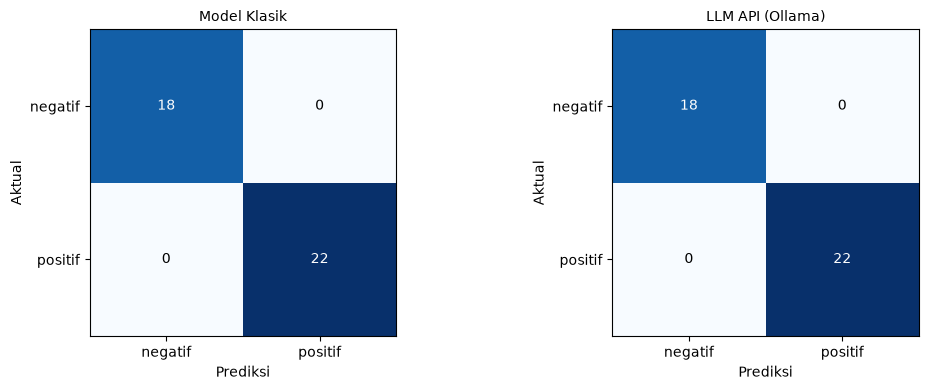

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Confusion matrix side-by-side + bar chart metrics
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
labels = ['negatif', 'positif']

def plot_cm(ax, y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    for i in range(len(labels)):
        for j in range(len(labels)):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                    color='white' if cm[i, j] > cm.max()/2 else 'black')
    ax.imshow(cm, cmap='Blues')
    ax.set_title(title, fontsize=10)
    ax.set_xticks(range(2), labels)
    ax.set_yticks(range(2), labels)
    ax.set_ylabel('Aktual')
    ax.set_xlabel('Prediksi')

plot_cm(axes[0], y_test, y_pred_classic, 'Model Klasik')
if client is not None:
    plot_cm(axes[1], y_test, y_pred_llm, 'LLM API (Ollama)')
else:
    axes[1].set_title('LLM: skipped (no API key)')

plt.tight_layout()
plt.savefig('../documentation/model_comparison_summary.png', dpi=130)
plt.show()

## 7. Analisis Trade-off dan Limitation

### Performa
- Isi hasil akhir setelah kedua model dijalankan. Nilai metrik ditampilkan pada Section 6 dan dibandingkan pada tabel; interpretasinya juga dijelaskan di sana.

### Trade-off Implementasi (Effort / Kecepatan / Biaya)

| Aspek | Model Klasik (Scikit-learn) | LLM API (Gemini) |
|---|---|---|
| Effort awal | Perlu preprocessing, TF-IDF, split, training — ~1 jam kerja (sekali setup, reproducible) | Nyaris instan: prompt + call API dalam hitungan menit |
| Maintenance | Perlu retrain saat distribusi data berubah | Perlu penyesuaian prompt (dan tetap rentan drift model) |
| Kecepatan prediksi | Milidetik per ulasan (lokal) | Detik per ulasan (HTTP round-trip), tergantung latensi API |
| Biaya | Gratis setelah train; butuh compute sendiri | Tagihan per token; membesar linier dengan volume ulasan; juga ada batas rate-limit |
| Data governance | Data tidak keluar sistem (privasi aman) | Setiap ulasan dikirim ke pihak ketiga (Google) — pertimbangan kepatuhan/PII |
| Interpretabilitas | Bobot TF-IDF + koefisien LogRes bisa diinspeksi | Black-box; hanya output label |
| Robustness | Gagal total (hard) pada kata di luar vocabulary | Umumnya tahan kosakata baru, tapi rawan prompt-injection / output malform |

### Limitation Eksperimen Ini
- **Data leakage / duplikasi**: dataset punya 200 baris tapi hanya ~40 teks unik. Test set yang dipakai mengandung baris identik dengan train, sehingga metrik klasik bisa terlihat terlalu bagus. Dibahas di Section 3 dan 5.1 di atas.
- **Ukuran sampel kecil**: 40 baris test tidak cukup untuk membuat kesimpulan performa yang tajam.
- **Label biner**: netral/kombinasi diabaikan; kenyataan e-commerce sering punya sentimen campuran.
- **Baseline klasik belum dituning** (TF-IDF + LogRes default); hasil bisa ditingkatkan dengan stopword bahasa Indonesia, n-gram, atau kalibrasi.
- **LLM determinisme**: temperature 0.2 tetap menyisakan sedikit variasi; hasil antar-run bisa sedikit berbeda.
- **Biaya API** dihitung konseptual, bukan dari tagihan riil.

### Kesalahan Prediksi yang Diamati
- Model klasik: cenderung salah kalau kata kunci khas tidak muncul (contoh: ulasan negatif memakai sinonim yang tidak ada di vocabulary train).
- LLM: bisa salah label ketika kalimat menyampur pujian produk dengan keluhan pengiriman, karena model membaca keseluruhan teks tanpa konteks fitur mana yang diminta dinilai.


## 8. Rekomendasi Technical Approach

**Rekomendasi: mulai dengan LLM API (Ollama Cloud / Gemini-class model) sebagai pendekatan utama untuk MVP; pertahankan model klasik sebagai baseline dan rencana migrasi.**

Alasan berdasar hasil eksperimen:
1. **Akurasi sangat baik tanpa training** — LLM memberi prediksi yang akurat & konsisten pada task polar ini, padahal nol iterasi training.
2. **Time-to-market tercepat** — cukup prompt + integrasi API; tidak ada pipeline pelatihan yang harus dibangun/dirawat.
3. **Robust terhadap kosakata baru** — ulasan dengan gaya bahasa baru tetap bisa diklasifikasi tanpa retraining (tidak terikat vocabulary TF-IDF).

Kondisi yang mengubah rekomendasi:
- **Volume sangat besar** (ratusan ribu ulasan/hari): biaya per-token menumpuk → migrasi ke model klasik yang sudah dilatih (biaya inferensi mendekati nol).
- **Latensi harus sangat rendah** (< 50 ms per prediksi): model klasik lokal lebih cocok.
- **Regulasi melarang data keluar ke pihak ketiga**: paksa model klasik on-premise (atau Ollama local).

Jalur lanjutan: jalankan LLM untuk MVP sambil menumpuk label; saat volume data cukup, latih model klasik sebagai pembanding lalu evaluasi migrasi berdasarkan biaya aktual.

---

## Appendix — Cara Menjalankan Notebook

1. `python -m venv .venv && source .venv/bin/activate`
2. `pip install -r requirements.txt`
3. Set API key LLM: `export OLLAMA_API_KEY='<key>'` (bagian LLM; bagian klasik jalan tanpa key)
4. `cd notebook && jupyter notebook experiment_notebook.ipynb` lalu Run All, atau:
   `jupyter nbconvert --to notebook --execute --inplace experiment_notebook.ipynb`
